# Convert beams

In [1]:
from pmd_beamphysics import ParticleGroup
from pmd_beamphysics.interfaces.elegant import elegant_to_data
import numpy as np
import os

In [2]:
F = '$LCLS_LATTICE/elegant/beams/FZ_100pC_10NOV17.sdds'
F = os.path.expandvars(F)
os.path.exists(F)

True

In [3]:
DAT = elegant_to_data(F, charge = 100e-12, sdds2plaindata_bin='/Users/chrisonian/Code/elegant/bin/sdds2plaindata')

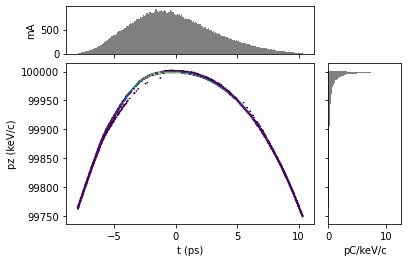

In [4]:
P = ParticleGroup(data=DAT)
P.plot('t', 'pz')

# Fake laser heater

In [6]:
dp = 5.0E-5  # From elegant model
P['mean_p']*dp  

4998.656789158192

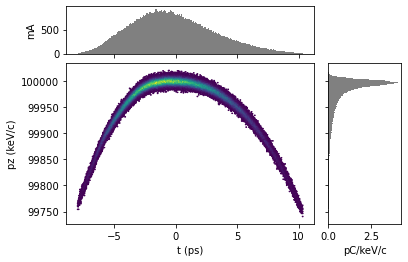

In [8]:
dpz = np.random.normal(scale=P['mean_p']*dp, size=len(P))
P.pz += dpz 
P.plot('t', 'pz')

In [9]:
OUTFILE = os.path.expandvars('$LCLS_LATTICE/bmad/beams/FZ_100pC_10NOV17_scattered_5keV_resampled_100k.beam0')
OUTFILE

'/Users/chrisonian/Code/GitHub/lcls-lattice//bmad/beams/FZ_100pC_10NOV17_scattered_5keV_resampled_100k.beam0'

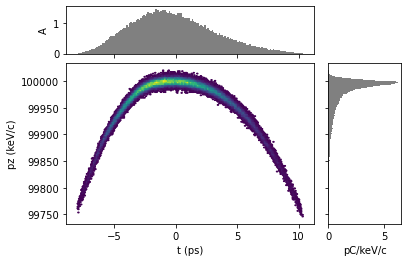

In [10]:
P1 = P.resample(100000)
#P1 = P[::10]
P1.plot('t', 'pz')

In [11]:
P1.write_bmad(OUTFILE, p0c=9.9998694E+07)

In [ ]:
P1